# User Churn Prediction Models

## Step 1 : Data Collection

In [10]:
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [11]:
conn = sqlite3.connect(r'D:\Imarticus Learning- PGA 45\GitHub Projects\h & m db\hm_database.db')
query = '''
SELECT c.customer_id, c.age, c.club_member_status, c.fashion_news_frequency, MAX(t.t_dat) as last_purchase_date, MIN(t.t_dat) as first_purchase_date, COUNT(t.article_id) as total_purchases, COUNT(DISTINCT t.article_id) as unique_articles, SUM(t.price) as total_spend, AVG(t.price) as avg_item_price
FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
GROUP BY c.customer_id;
'''
df = pd.read_sql_query(query, conn)
conn.close()

In [12]:
df.head()

,customer_id,age,club_member_status,fashion_news_frequency,last_purchase_date,first_purchase_date,total_purchases,unique_articles,total_spend,avg_item_price
0,0,49.0,ACTIVE,NONE,2020-09-05,2019-09-18,13,12,0.393186,0.030245
1,1,25.0,ACTIVE,NONE,2020-07-08,2019-10-24,35,25,0.887542,0.025358
2,2,24.0,ACTIVE,NONE,2020-09-15,2020-02-03,14,11,0.559085,0.039935
3,4,52.0,ACTIVE,Regularly,2020-08-12,2019-10-01,9,8,0.359593,0.039955
4,5,NaN,None,None,2019-10-02,2019-10-02,3,3,0.101644,0.033881


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007704 entries, 0 to 1007703
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1007704 non-null  int64  
 1   age                     999582 non-null   float64
 2   club_member_status      1004926 non-null  object 
 3   fashion_news_frequency  994416 non-null   object 
 4   last_purchase_date      1007704 non-null  object 
 5   first_purchase_date     1007704 non-null  object 
 6   total_purchases         1007704 non-null  int64  
 7   unique_articles         1007704 non-null  int64  
 8   total_spend             1007704 non-null  float64
 9   avg_item_price          1007704 non-null  float64
dtypes: float64(3), int64(3), object(4)
memory usage: 76.9+ MB


In [14]:
print("Extracting Last 30-Day Spend from Database...")

# 1. Re-open the connection!
conn = sqlite3.connect(r'D:\Imarticus Learning- PGA 45\GitHub Projects\h & m db\hm_database.db')

# 2. Run the query
query_30_days = '''
WITH MaxDate AS (
    SELECT MAX(t_dat) as global_max FROM transactions
)
SELECT customer_id, SUM(price) as spend_last_30_days
FROM transactions
WHERE t_dat >= date((SELECT global_max FROM MaxDate), '-30 days')
GROUP BY customer_id
'''

df_30 = pd.read_sql_query(query_30_days, conn)

# 3. Close the connection again to save memory
conn.close()

# 4. Merge this new feature into your main dataframe (df)
df = df.merge(df_30, on='customer_id', how='left')

# 5. If they didn't buy anything in the last 30 days, their spend is 0
df['spend_last_30_days'] = df['spend_last_30_days'].fillna(0)

print("Advanced Feature Added Successfully!")
print(df[['customer_id', 'total_spend', 'spend_last_30_days']].head())

Extracting Last 30-Day Spend from Database...
Advanced Feature Added Successfully!
   customer_id  total_spend  spend_last_30_days
0            0     0.393186            0.050831
1            1     0.887542            0.000000
2            2     0.559085            0.061000
3            4     0.359593            0.000000
4            5     0.101644            0.000000


In [15]:
df.describe(include="all")

,customer_id,age,club_member_status,fashion_news_frequency,last_purchase_date,first_purchase_date,total_purchases,unique_articles,total_spend,avg_item_price,spend_last_30_days
count,1.007704e+06,999582.000000,1004926,994416,1007704,1007704,1.007704e+06,1.007704e+06,1.007704e+06,1.007704e+06,1.007704e+06
unique,NaN,NaN,3,3,382,382,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,ACTIVE,NONE,2020-09-18,2019-09-28,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,963399,621880,11180,26350,NaN,NaN,NaN,NaN,NaN
mean,6.859201e+05,35.748646,NaN,NaN,NaN,NaN,1.533551e+01,1.324819e+01,4.352761e-01,2.930100e-02,3.761378e-02
std,3.960881e+05,14.266974,NaN,NaN,NaN,NaN,2.261534e+01,1.844789e+01,7.028149e-01,1.445136e-02,1.153155e-01
min,0.000000e+00,16.000000,NaN,NaN,NaN,NaN,1.000000e+00,1.000000e+00,7.627119e-04,5.593220e-04,0.000000e+00
25%,3.427948e+05,24.000000,NaN,NaN,NaN,NaN,3.000000e+00,3.000000e+00,8.467797e-02,2.116949e-02,0.000000e+00
50%,6.857080e+05,31.000000,NaN,NaN,NaN,NaN,8.000000e+00,7.000000e+00,2.049492e-01,2.667458e-02,0.000000e+00
75%,1.028981e+06,48.000000,NaN,NaN,NaN,NaN,1.800000e+01,1.600000e+01,4.988136e-01,3.388136e-02,0.000000e+00


## Step 2 : Data Cleaning & Preprocessing

In [16]:
df.columns

Index(['customer_id', 'age', 'club_member_status', 'fashion_news_frequency',
       'last_purchase_date', 'first_purchase_date', 'total_purchases',
       'unique_articles', 'total_spend', 'avg_item_price',
       'spend_last_30_days'],
      dtype='object')

### Correct Data Types

In [17]:
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])
df['first_purchase_date'] = pd.to_datetime(df['first_purchase_date'])

In [18]:
df.info() # Verify data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007704 entries, 0 to 1007703
Data columns (total 11 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   customer_id             1007704 non-null  int64         
 1   age                     999582 non-null   float64       
 2   club_member_status      1004926 non-null  object        
 3   fashion_news_frequency  994416 non-null   object        
 4   last_purchase_date      1007704 non-null  datetime64[ns]
 5   first_purchase_date     1007704 non-null  datetime64[ns]
 6   total_purchases         1007704 non-null  int64         
 7   unique_articles         1007704 non-null  int64         
 8   total_spend             1007704 non-null  float64       
 9   avg_item_price          1007704 non-null  float64       
 10  spend_last_30_days      1007704 non-null  float64       
dtypes: datetime64[ns](2), float64(4), int64(3), object(2)
memory usage: 84.6+ MB

### Feature Enginnering

In [19]:
df['customer_lifetime_days'] = (df['last_purchase_date'] - df['first_purchase_date']).dt.days
# Avoid division by zero by replacing 0 lifetime with 1
df['customer_lifetime_days'] = df['customer_lifetime_days'].replace(0, 1)
df['avg_days_between_purchases'] = df['customer_lifetime_days'] / df['total_purchases']
df['unique_to_total_ratio'] = df['unique_articles'] / df['total_purchases']

In [20]:
df[['customer_lifetime_days', 'avg_days_between_purchases', 'unique_to_total_ratio']].head()

,customer_lifetime_days,avg_days_between_purchases,unique_to_total_ratio
0,353,27.153846,0.923077
1,258,7.371429,0.714286
2,225,16.071429,0.785714
3,316,35.111111,0.888889
4,1,0.333333,1.000000


### Define Churn Target

In [21]:
max_date = df['last_purchase_date'].max()
df['churn'] = ((max_date - df['last_purchase_date']).dt.days > 90).astype(int)

### Check Missing Values

In [22]:
df.isnull().sum()

customer_id                       0
age                            8122
club_member_status             2778
fashion_news_frequency        13288
last_purchase_date                0
first_purchase_date               0
total_purchases                   0
unique_articles                   0
total_spend                       0
avg_item_price                    0
spend_last_30_days                0
customer_lifetime_days            0
avg_days_between_purchases        0
unique_to_total_ratio             0
churn                             0
dtype: int64

### Handle Missing Values

In [23]:
df['age'] = df['age'].fillna(df['age'].median())
df['club_member_status'] = df['club_member_status'].fillna('NONE')
df['fashion_news_frequency'] = df['fashion_news_frequency'].fillna('NONE')

In [24]:
df.isnull().sum()

customer_id                   0
age                           0
club_member_status            0
fashion_news_frequency        0
last_purchase_date            0
first_purchase_date           0
total_purchases               0
unique_articles               0
total_spend                   0
avg_item_price                0
spend_last_30_days            0
customer_lifetime_days        0
avg_days_between_purchases    0
unique_to_total_ratio         0
churn                         0
dtype: int64

### Encoding Categorical Variables

In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['club_member_status'] = le.fit_transform(df['club_member_status'])
df['fashion_news_frequency'] = le.fit_transform(df['fashion_news_frequency'])

### Scale Features

In [26]:
from sklearn.preprocessing import StandardScaler
X = df[['age', 'club_member_status', 'fashion_news_frequency', 'total_purchases', 'total_spend']]
y = df['churn']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 3 : EDA

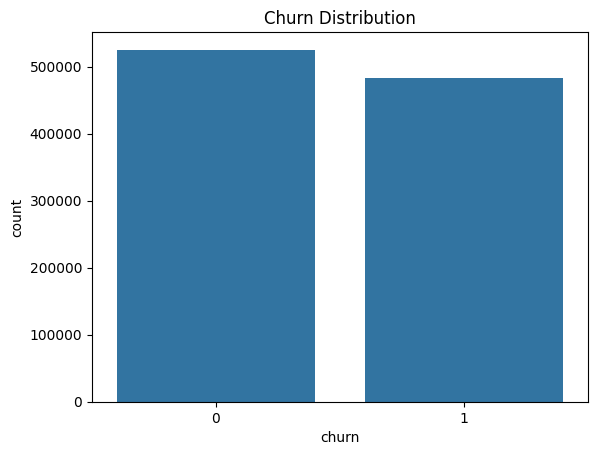

churn
0    52.106075
1    47.893925
Name: proportion, dtype: float64


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='churn', data=df)
plt.title('Churn Distribution')
plt.show()

# Print The results
print(df['churn'].value_counts(normalize=True) * 100)

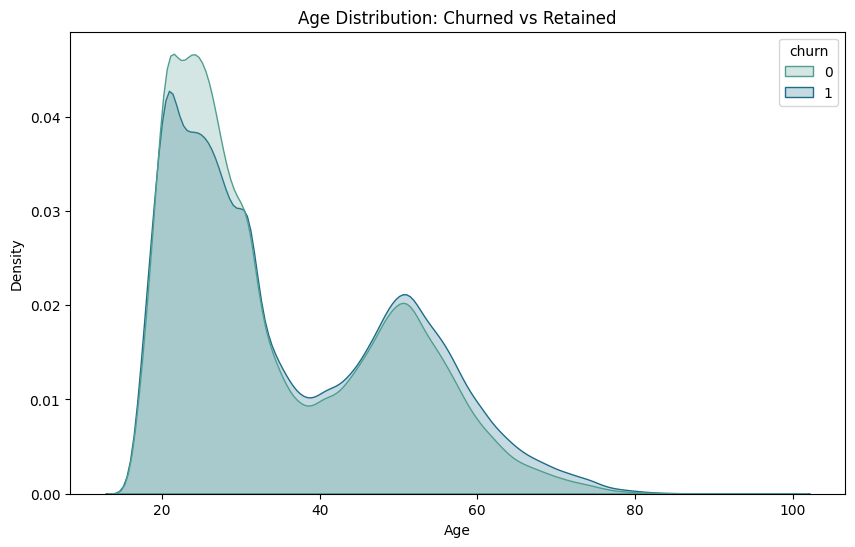

In [28]:
# Age Distribution by Churn
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='age', hue='churn', fill=True, common_norm=False, palette='crest')
plt.title('Age Distribution: Churned vs Retained')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

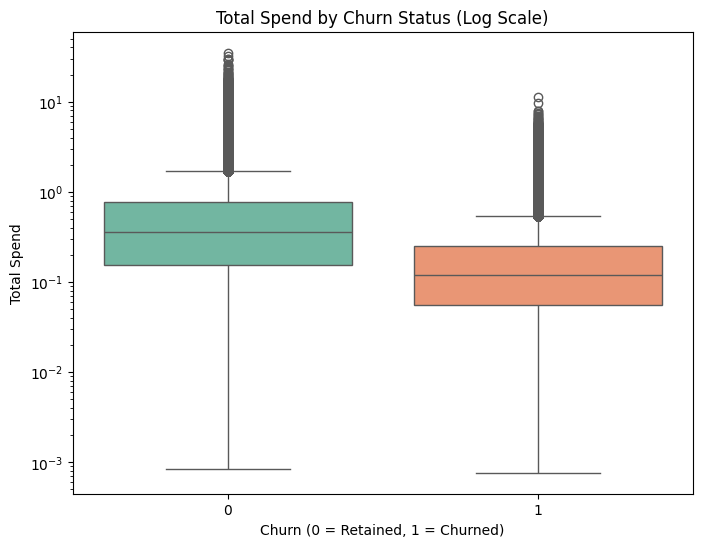

In [29]:
# Total Spend by Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='churn', y='total_spend', data=df, palette='Set2')
plt.yscale('log') # Log scale to handle massive outliers
plt.title('Total Spend by Churn Status (Log Scale)')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Total Spend')
plt.show()

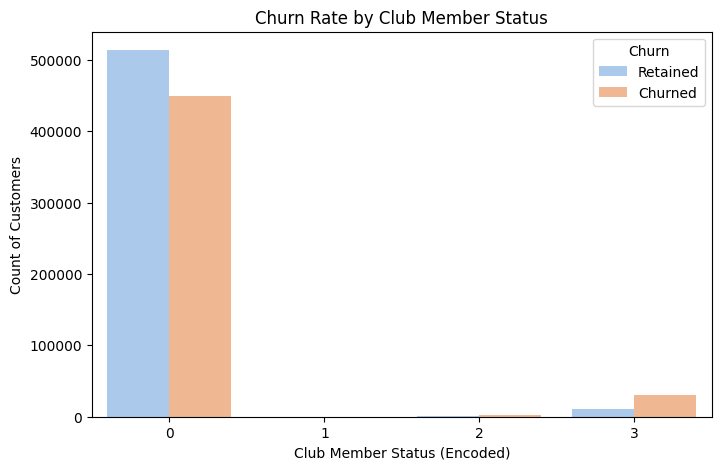

In [30]:
# Club Member Status vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='club_member_status', hue='churn', data=df, palette='pastel')
plt.title('Churn Rate by Club Member Status')
plt.xlabel('Club Member Status (Encoded)')
plt.ylabel('Count of Customers')
plt.legend(title='Churn', labels=['Retained', 'Churned'])
plt.show()

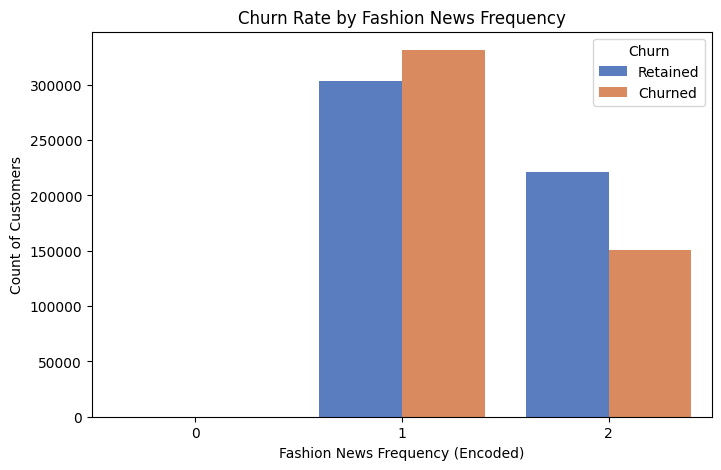

In [31]:
# Fashion News Frequency vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='fashion_news_frequency', hue='churn', data=df, palette='muted')
plt.title('Churn Rate by Fashion News Frequency')
plt.xlabel('Fashion News Frequency (Encoded)')
plt.ylabel('Count of Customers')
plt.legend(title='Churn', labels=['Retained', 'Churned'])
plt.show()

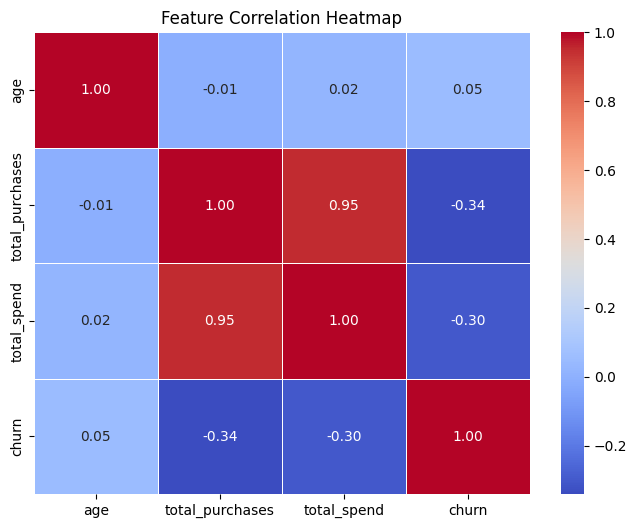

In [32]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
# We drop the date column for correlation
corr_matrix = df[['age', 'total_purchases', 'total_spend', 'churn']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## Step 4 : Data Spliting

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
print(X_train.shape)
print()
print(y_train.shape)
print()
print(X_test.shape)
print()
print(y_test.shape)

(806163, 5)

(806163,)

(201541, 5)

(201541,)


## Step 5 : Model Building

### 5.1 Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [36]:
# Predictions 

Y_pred_prob= lr.predict_proba(X_test)
Y_pred_prob

array([[0.39815288, 0.60184712],
       [0.22066739, 0.77933261],
       [0.99381551, 0.00618449],
       ...,
       [0.83595482, 0.16404518],
       [0.30175371, 0.69824629],
       [0.68748108, 0.31251892]], shape=(201541, 2))

In [37]:
Y_pred = lr.predict(X_test)

In [38]:
list(zip(y_test,Y_pred))

[(1, np.int64(1)),
 (0, np.int64(1)),
 (0, np.int64(0)),
 (0, np.int64(1)),
 (0, np.int64(0)),
 (1, np.int64(1)),
 (1, np.int64(0)),
 (1, np.int64(1)),
 (0, np.int64(0)),
 (1, np.int64(1)),
 (1, np.int64(1)),
 (0, np.int64(1)),
 (0, np.int64(0)),
 (1, np.int64(1)),
 (0, np.int64(1)),
 (0, np.int64(1)),
 (0, np.int64(1)),
 (0, np.int64(0)),
 (1, np.int64(1)),
 (1, np.int64(0)),
 (0, np.int64(1)),
 (0, np.int64(1)),
 (0, np.int64(0)),
 (0, np.int64(1)),
 (1, np.int64(1)),
 (0, np.int64(1)),
 (0, np.int64(0)),
 (1, np.int64(0)),
 (0, np.int64(0)),
 (1, np.int64(1)),
 (1, np.int64(1)),
 (0, np.int64(0)),
 (1, np.int64(1)),
 (1, np.int64(1)),
 (0, np.int64(1)),
 (0, np.int64(0)),
 (0, np.int64(1)),
 (0, np.int64(0)),
 (1, np.int64(1)),
 (1, np.int64(1)),
 (0, np.int64(0)),
 (0, np.int64(1)),
 (1, np.int64(0)),
 (0, np.int64(1)),
 (1, np.int64(1)),
 (1, np.int64(1)),
 (0, np.int64(1)),
 (0, np.int64(0)),
 (0, np.int64(1)),
 (0, np.int64(0)),
 (0, np.int64(0)),
 (0, np.int64(1)),
 (1, np.int6

Confusion matrix:-
[[64184 40831]
 [19728 76798]]

Accuracy Score: 0.6995201968830164

Classfication Report :-
              precision    recall  f1-score   support

           0       0.76      0.61      0.68    105015
           1       0.65      0.80      0.72     96526

    accuracy                           0.70    201541
   macro avg       0.71      0.70      0.70    201541
weighted avg       0.71      0.70      0.70    201541



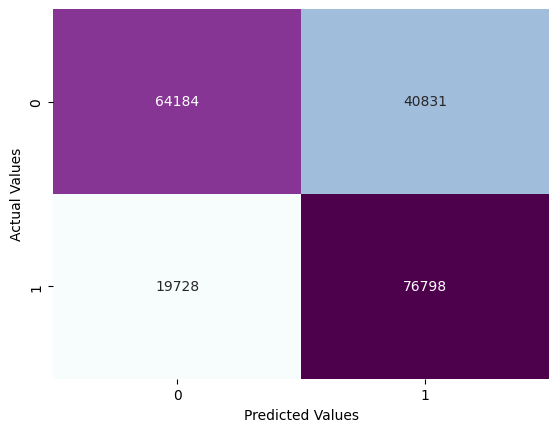

In [39]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cfm =confusion_matrix(y_test,Y_pred)
print("Confusion matrix:-")
print(cfm)
print()
acc = accuracy_score(y_test,Y_pred)
print("Accuracy Score:",acc)
print()
print("Classfication Report :-")
print(classification_report(y_test,Y_pred))

sns.heatmap(cfm,annot = True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [40]:
# print the scores on training and testing set
print("Training set score:{:.4f}".format(lr.score(X_train,y_train)))
print("Testing set score:{:.4f}".format(lr.score(X_test,y_test)))

Training set score:0.7001
Testing set score:0.6995


### 5.2 Decision Tree

In [41]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(class_weight='balanced',max_depth=7,random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=7, random_state=42)

In [42]:
Y_pred = dt.predict(X_test)
print(Y_pred)
#print(list(zip(Y_test,Y_pred)))

[1 1 0 ... 0 1 0]


Confusion matrix:-
[[68794 36221]
 [23623 72903]]

Accuracy Score: 0.7030678621223473

Classfication Report :-
              precision    recall  f1-score   support

           0       0.74      0.66      0.70    105015
           1       0.67      0.76      0.71     96526

    accuracy                           0.70    201541
   macro avg       0.71      0.71      0.70    201541
weighted avg       0.71      0.70      0.70    201541



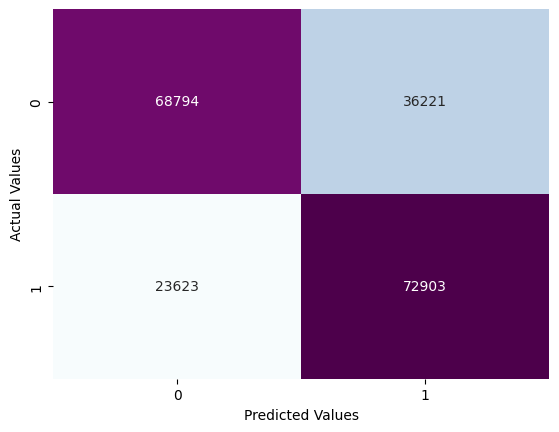

In [43]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cfm =confusion_matrix(y_test,Y_pred)
print("Confusion matrix:-")
print(cfm)
print()
acc = accuracy_score(y_test,Y_pred)
print("Accuracy Score:",acc)
print()
print("Classfication Report :-")
print(classification_report(y_test,Y_pred))

sns.heatmap(cfm,annot = True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [44]:
# print the scores on training and testing set
print("Training set score:{:.4f}".format(dt.score(X_train,y_train)))
print("Testing set score:{:.4f}".format(dt.score(X_test,y_test)))

Training set score:0.7040
Testing set score:0.7031


### 5.3 Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
# We use 100 trees (n_estimators=100) and limit depth to 7
rf = RandomForestClassifier(max_depth=7, n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, random_state=42)

In [46]:
Y_pred = rf.predict(X_test)
print(Y_pred)
#print(list(zip(Y_test,Y_pred)))

[1 1 0 ... 0 1 0]


Confusion matrix:-
[[71162 33853]
 [25575 70951]]

Accuracy Score: 0.7051319582615944

Classfication Report :-
              precision    recall  f1-score   support

           0       0.74      0.68      0.71    105015
           1       0.68      0.74      0.70     96526

    accuracy                           0.71    201541
   macro avg       0.71      0.71      0.71    201541
weighted avg       0.71      0.71      0.71    201541



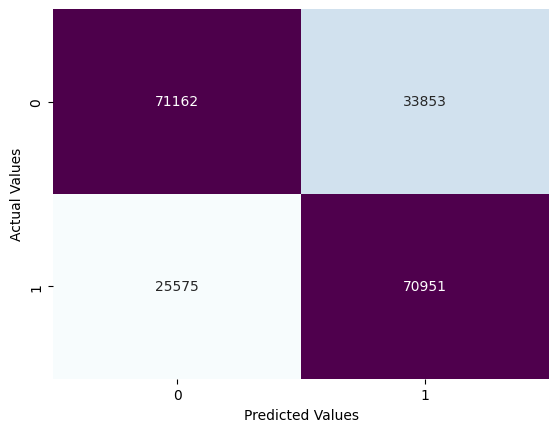

In [47]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cfm =confusion_matrix(y_test,Y_pred)
print("Confusion matrix:-")
print(cfm)
print()
acc = accuracy_score(y_test,Y_pred)
print("Accuracy Score:",acc)
print()
print("Classfication Report :-")
print(classification_report(y_test,Y_pred))

sns.heatmap(cfm,annot = True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [48]:
# print the scores on training and testing set
print("Training set score:{:.4f}".format(rf.score(X_train,y_train)))
print("Testing set score:{:.4f}".format(rf.score(X_test,y_test)))

Training set score:0.7054
Testing set score:0.7051


### 5.4 XGBoost

In [49]:
! pip install --upgrade xgboost

Defaulting to user installation because normal site-packages is not writeable


In [50]:
from xgboost import XGBClassifier

xgb = XGBClassifier(max_depth=5, learning_rate=0.1, n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [51]:
Y_pred = xgb.predict(X_test)
print(Y_pred)
#print(list(zip(Y_test,Y_pred)))

[1 1 0 ... 0 1 0]


Confusion matrix:-
[[71747 33268]
 [25913 70613]]

Accuracy Score: 0.7063575153442724

Classfication Report :-
              precision    recall  f1-score   support

           0       0.73      0.68      0.71    105015
           1       0.68      0.73      0.70     96526

    accuracy                           0.71    201541
   macro avg       0.71      0.71      0.71    201541
weighted avg       0.71      0.71      0.71    201541



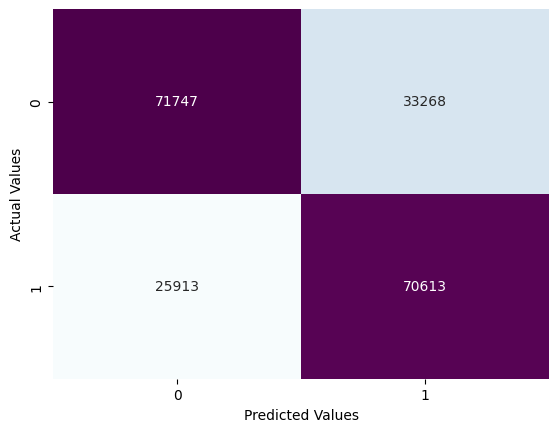

In [52]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cfm =confusion_matrix(y_test,Y_pred)
print("Confusion matrix:-")
print(cfm)
print()
acc = accuracy_score(y_test,Y_pred)
print("Accuracy Score:",acc)
print()
print("Classfication Report :-")
print(classification_report(y_test,Y_pred))

sns.heatmap(cfm,annot = True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [53]:
# print the scores on training and testing set
print("Training set score:{:.4f}".format(xgb.score(X_train,y_train)))
print("Testing set score:{:.4f}".format(xgb.score(X_test,y_test)))

Training set score:0.7065
Testing set score:0.7064


### 5.5 LightGBM

In [54]:
! pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [55]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(max_depth=5, learning_rate=0.1, n_estimators=100, random_state=42)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 386103, number of negative: 420060
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 597
[LightGBM] [Info] Number of data points in the train set: 806163, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.478939 -> initscore=-0.084293
[LightGBM] [Info] Start training from score -0.084293
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier(max_depth=5, random_state=42)

In [56]:
Y_pred = lgbm.predict(X_test)
print(Y_pred)
#print(list(zip(Y_test,Y_pred)))

[1 1 0 ... 0 1 0]


Confusion matrix:-
[[71672 33343]
 [25833 70693]]

Accuracy Score: 0.7063823241920999

Classfication Report :-
              precision    recall  f1-score   support

           0       0.74      0.68      0.71    105015
           1       0.68      0.73      0.70     96526

    accuracy                           0.71    201541
   macro avg       0.71      0.71      0.71    201541
weighted avg       0.71      0.71      0.71    201541



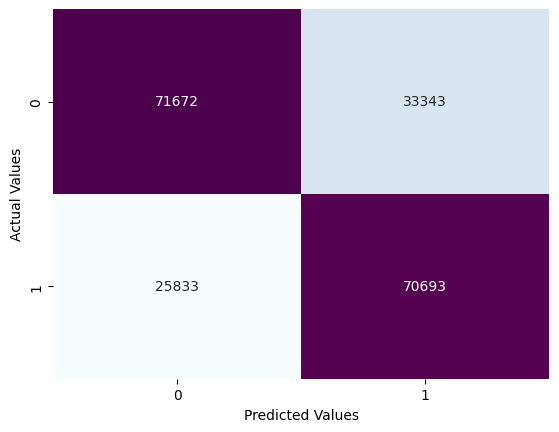

In [57]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cfm =confusion_matrix(y_test,Y_pred)
print("Confusion matrix:-")
print(cfm)
print()
acc = accuracy_score(y_test,Y_pred)
print("Accuracy Score:",acc)
print()
print("Classfication Report :-")
print(classification_report(y_test,Y_pred))

sns.heatmap(cfm,annot = True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [58]:
# print the scores on training and testing set
print("Training set score:{:.4f}".format(lgbm.score(X_train,y_train)))
print("Testing set score:{:.4f}".format(lgbm.score(X_test,y_test)))

Training set score:0.7065
Testing set score:0.7064


## Step 6 : Model Evaluation

In [59]:
from sklearn.metrics import classification_report, roc_auc_score

In [60]:
print('Logistic Regression:')
print(classification_report(y_test, lr.predict(X_test)))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.76      0.61      0.68    105015
           1       0.65      0.80      0.72     96526

    accuracy                           0.70    201541
   macro avg       0.71      0.70      0.70    201541
weighted avg       0.71      0.70      0.70    201541



In [61]:
print('XGBoost ROC-AUC:', roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))

XGBoost ROC-AUC: 0.7728746850808732


## Step 7 : Model Tuning

### Basic Tuning: GridSearch on Decision Tree

In [62]:
from sklearn.model_selection import GridSearchCV
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), {'max_depth': [3, 5, 10]}, cv=3)
dt_grid.fit(X_train, y_train)
print('Best DT Params:', dt_grid.best_params_)

Best DT Params: {'max_depth': 10}


### Advanced Tuning: RandomizedSearch on XGBoost

In [63]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200],  
    'max_depth': [3, 5, 7]
}

xgb_rand = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42), 
    param_distributions=param_grid, 
    n_iter=5, 
    cv=3, 
    scoring='accuracy', # Changed to Accuracy because data is perfectly balanced!
    random_state=42,
    n_jobs=-1
)

xgb_rand.fit(X_train, y_train)
best_xgb = xgb_rand.best_estimator_

In [64]:
# Predict using the winning model
y_pred_train = best_xgb.predict(X_train)
y_pred_test = best_xgb.predict(X_test)

# Print the results
print("Confusion matrix:-")
print(confusion_matrix(y_test, y_pred_test))

print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred_test):.5f}")

print("\nClassification Report :-")
print(classification_report(y_test, y_pred_test))

print(f"\nTraining set score: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Testing set score: {accuracy_score(y_test, y_pred_test):.4f}")

Confusion matrix:-
[[71593 33422]
 [25805 70721]]

Accuracy Score: 0.70613

Classification Report :-
              precision    recall  f1-score   support

           0       0.74      0.68      0.71    105015
           1       0.68      0.73      0.70     96526

    accuracy                           0.71    201541
   macro avg       0.71      0.71      0.71    201541
weighted avg       0.71      0.71      0.71    201541


Training set score: 0.7062
Testing set score: 0.7061


In [65]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Building the Stacking Super-Model... (This might take a minute!)")

# 1. Define the Base Models (The 'Workers')
base_models = [
    ('rf', RandomForestClassifier(max_depth=7, n_estimators=100, random_state=42)),
    ('lgbm', lgb.LGBMClassifier(max_depth=5, learning_rate=0.1, n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(max_depth=5, learning_rate=0.1, n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42))
]

# 2. Define the Meta-Model (The 'Boss')
meta_model = LogisticRegression(random_state=42)

# 3. Create and Train the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models, 
    final_estimator=meta_model,
    cv=3, # Cross-validation folds to prevent overfitting
    n_jobs=-1 # Use all CPU cores!
)

stacking_clf.fit(X_train, y_train)

# 4. Evaluate the Super-Model
y_pred_stack = stacking_clf.predict(X_test)

print('\n--- STACKING CLASSIFIER RESULTS ---')
print('Confusion matrix:-')
print(confusion_matrix(y_test, y_pred_stack))
print(f'\nAccuracy Score: {accuracy_score(y_test, y_pred_stack):.5f}')
print('\nClassification Report :-')
print(classification_report(y_test, y_pred_stack))


Building the Stacking Super-Model... (This might take a minute!)

--- STACKING CLASSIFIER RESULTS ---
Confusion matrix:-
[[72644 32371]
 [26788 69738]]

Accuracy Score: 0.70647

Classification Report :-
              precision    recall  f1-score   support

           0       0.73      0.69      0.71    105015
           1       0.68      0.72      0.70     96526

    accuracy                           0.71    201541
   macro avg       0.71      0.71      0.71    201541
weighted avg       0.71      0.71      0.71    201541



## Step 8 : Model Deployment

In [66]:
import joblib
joblib.dump(best_xgb, 'churn_xgb.pkl')

['churn_xgb.pkl']